In [96]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize, StandardScaler
import os
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools
import numpy as np

In [97]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

In [98]:
def build_kmer_dataset(df, k, file_name, output_dir='../data/sequences_kmers'):
    
    bases = ['A', 'C', 'G', 'T']
    all_kmers = [''.join(p) for p in itertools.product(bases, repeat=k)]
    
    def make_kmers(seq):
        return ' '.join([seq[i:i+k] for i in range(len(seq) - k + 1)])
    
    kmers_text = df['Sequence'].apply(make_kmers) 

    
    vectorizer = CountVectorizer(vocabulary=all_kmers,lowercase=False)
    X_counts = vectorizer.fit_transform(kmers_text)

    X_freq = normalize(X_counts, norm='l1', axis=1)
    
    feature_names = vectorizer.get_feature_names_out()
    
    df_kmers = pd.DataFrame(X_freq.toarray(), columns=feature_names)
    df_final = pd.concat([df.reset_index(drop=True), df_kmers.reset_index(drop=True)], axis=1)
    
       
    path = os.path.join(output_dir, file_name)
    df_final.to_csv(path, index=False)    
    
    return df_final

In [99]:
def plot_cumulative_variance(df, dataset_label='Dataset'):
    
    cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0', 'Accession', 'Species','Segment', 'Nuc_Completeness', 'Sequence']

    X = df.drop(columns=cols_to_drop)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=None)
    pca.fit(X_scaled)
    
    cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
    n_components = len(cum_var)
    
    plt.figure(figsize=(9, 5))
    plt.plot(range(1, n_components + 1), cum_var, marker='o', markersize=2, linestyle='-', label='Kumulativna varijansa')
    
    plt.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='Prag 80%')
    plt.axhline(y=90, color='green', linestyle='--', alpha=0.7, label='Prag 90%')
    
    plt.xlabel('Broj glavnih komponenti (PCA)', fontsize=11)
    plt.ylabel('Objašnjena varijansa (%)', fontsize=11)
    plt.title(f'Kumulativna objašnjena varijansa - {dataset_label}', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    
    plt.show()
    
    n_80 = np.argmax(cum_var >= 80) + 1
    n_90 = np.argmax(cum_var >= 90) + 1
    print(f'[{dataset_label}] Broj komponenti za 80% varijanse: {n_80}')
    print(f'[{dataset_label}] Broj komponenti za 90% varijanse: {n_90}')

In [100]:
def apply_pca_transformation(df, n_components=3):

    
    cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0', 'Accession', 'Species','Segment', 'Nuc_Completeness', 'Sequence']

    X = df.drop(columns=cols_to_drop)
    species = df['Species'].values
    segments = df['Segment'].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    return X_pca, pca, species, segments

# Učitavanje podataka

In [101]:
complete_sequences_df = pd.read_csv('../data/processed_sequences/final/complete_sequences.csv')

In [102]:
total_count = len(complete_sequences_df)
species_counts = complete_sequences_df['Species'].value_counts()
print(total_count,species_counts)

427 Species
Orthohantavirus hantanense       249
Orthohantavirus puumalaense      123
Orthohantavirus dobravaense       37
Orthohantavirus sinnombreense     18
Name: count, dtype: int64


In [103]:
all_sequences_df = pd.read_csv('../data/processed_sequences/final/all_sequences.csv')

In [104]:
total_count = len(all_sequences_df)
species_counts = all_sequences_df['Species'].value_counts()
print(total_count,species_counts)

6953 Species
Orthohantavirus puumalaense      3625
Orthohantavirus hantanense       2199
Orthohantavirus dobravaense       771
Orthohantavirus sinnombreense     358
Name: count, dtype: int64


In [105]:
all_4_mers = build_kmer_dataset(all_sequences_df,4,'all_4_mers.csv')

In [106]:
complete_4_mers = build_kmer_dataset(complete_sequences_df,4,'complete_4_mers.csv')

## Kumulativna objašnjena varijansa za sve 4-mere 

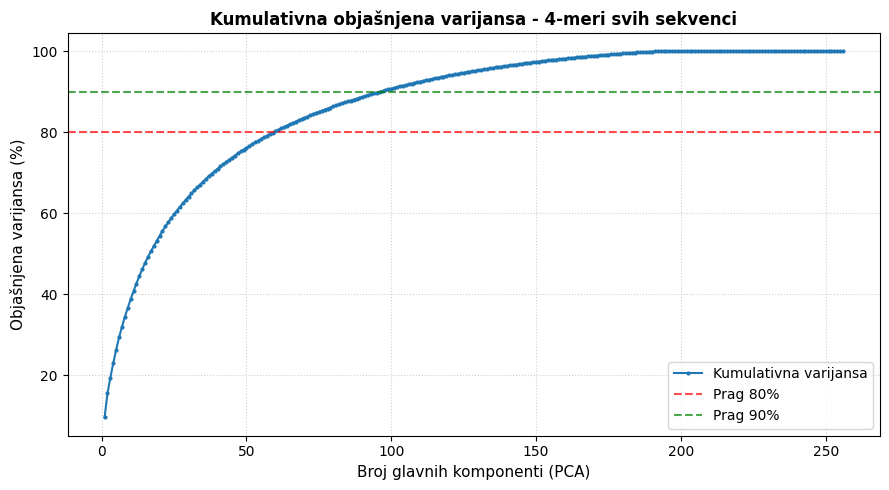

[4-meri svih sekvenci] Broj komponenti za 80% varijanse: 60
[4-meri svih sekvenci] Broj komponenti za 90% varijanse: 97


In [107]:
plot_cumulative_variance(all_4_mers,'4-meri svih sekvenci')

## Kumulativna objašnjena varijansa za 4-mere kompletnih sekvenci

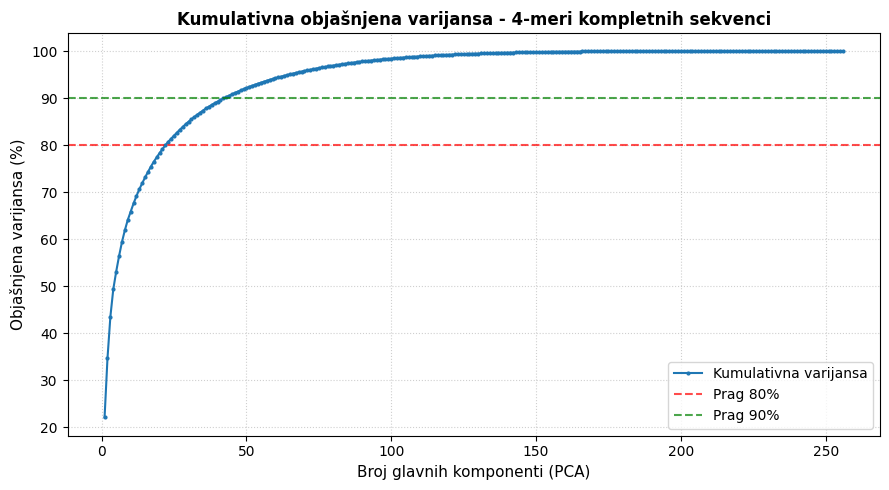

[4-meri kompletnih sekvenci] Broj komponenti za 80% varijanse: 23
[4-meri kompletnih sekvenci] Broj komponenti za 90% varijanse: 43


In [108]:
plot_cumulative_variance(complete_4_mers,'4-meri kompletnih sekvenci')

Iako analiza objašnjene varijanse sugeriše potrebu za 23 (odnosno 60) komponenti, zadržavanje ovako visokog broja dimenzija nad ograničenim brojem instanci 427 (odnosno ukupno 6953) dovelo bi do ekstremne retkosti prostora (engl. data sparsity). U uslovima gde je broj dimenzija previsok u odnosu na raspoloživi broj instanci, dolazi do izražaja prokletstvo dimenzionalnosti, zbog čega bi euklidska rastojanja izgubila informativnu vrednost. Iz tog razloga, redukcija na niži prostor bila je nužna kako bi se očuvala statistička stabilnost klasterovanja. Nadalje je primenjena redukcija broja komponenti na 3, radi vizuelizacije, stabilnosti metrika i pravednosti pri upoređivanju.

# Analiza 4-mera kompletnih nukleotida

In [109]:
X_pca, pca, species, segments = apply_pca_transformation(complete_4_mers)

# 1. K-Means

In [172]:
def optimize_and_print_kmeans(X_pca, cluster_range=range(2, 9)):
    
    best_score = -1
    best_params = {}
    best_labels = None
    best_metrics = {}
    
    algorithms = ['lloyd', 'elkan']
    inits = ['k-means++', 'random']
    
    for k in cluster_range:
        for alg in algorithms:
            for init_method in inits:
                kmeans = KMeans(
                    n_clusters=k, 
                    init=init_method, 
                    algorithm=alg, 
                    n_init=10, 
                    random_state=42
                )
                labels = kmeans.fit_predict(X_pca)
                
                # Računanje metrika
                sil_score = silhouette_score(X_pca, labels)
                db_score = davies_bouldin_score(X_pca, labels)
                
                if sil_score > best_score:
                    best_score = sil_score
                    best_params = {
                        'n_clusters': k,
                        'algorithm': alg,
                        'init': init_method
                    }
                    best_labels = labels
                    best_metrics = {
                        'silhouette': sil_score,
                        'davies_bouldin': db_score
                    }
                    
    print('=== NAJBOLJI K-MEANS REZULTATI ===')
    print(f"Optimalan broj klastera: {best_params['n_clusters']}")
    print(f"Izabrani algoritam: {best_params['algorithm']}")
    print(f"Način inicijalizacije: {best_params['init']}")
    print('-' * 40)
    print(f"Silhouette Score: {best_metrics['silhouette']:.4f}")
    print(f"Davies-Bouldin Index: {best_metrics['davies_bouldin']:.4f}")
    
    return best_params, best_metrics, best_labels

In [173]:
kmeans_params, kmeans_metrics, kmeans_labels = optimize_and_print_kmeans(X_pca, cluster_range=range(2, 8))

=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 4
Izabrani algoritam: lloyd
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.7665
Davies-Bouldin Index: 0.3323


In [174]:
df_kmeans_eval = pd.DataFrame({'Species': species,'Segments' : segments ,'Cluster': kmeans_labels})

In [175]:
seg_cluster_crosstab = pd.crosstab(df_kmeans_eval['Cluster'], df_kmeans_eval['Segments'])
print('=== Unakrsna tabela: Klasteri i segmenti (K-Means) ===')
print(seg_cluster_crosstab)

=== Unakrsna tabela: Klasteri i segmenti (K-Means) ===
Segments    L    M    S
Cluster                
0         130    0    6
1           0    0  109
2           0  129    0
3           0    0   53


In [176]:
species_cluster_crosstab = pd.crosstab(df_kmeans_eval['Cluster'], df_kmeans_eval['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (K-Means) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (K-Means) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  7                          86   
1                                 18                          91   
2                                 12                          72   
3                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                 31                             12  
1                                  0                              0  
2                                 39                              6  
3                                 53                              0  


Na osnovu unakrsne tabele uočava se da je klasterovanje izvršeno primarno na osnovu tipa segmenta. L segmenti pripadaju nultom klasteru, svi M segmenti drugom, dok su S segmenti podeljeni između prvog i trećeg klastera sa nekoliko instanci unutar nultog. Sa druge strane, različite vrste hantavirusa nisu grupisane po klasterima, iz čega se zaključuje da su k-mer profili međusobno znatno sličniji unutar istog genomskog segmenta nego unutar iste taksonomske vrste virusa.

# 2. Aglomerativno hijerarhijsko klasterovanje

In [178]:
def optimize_and_print_agglomerative(X_pca, cluster_range=range(2, 9)):
   
    best_score = -1
    best_params = {}
    best_labels = None
    best_metrics = {}
    
    metrics_list = ['euclidean', 'manhattan', 'cosine']
    linkages = ['ward', 'complete', 'average', 'single']
    
    for k in cluster_range:
        for metric in metrics_list:
            for linkage in linkages:
                # Ward zahteva isključivo euklidsku distancu
                if linkage == 'ward' and metric != 'euclidean':
                    continue
                
                model = AgglomerativeClustering(n_clusters=k, metric=metric, linkage=linkage)
                labels = model.fit_predict(X_pca)
                    
                sil_score = silhouette_score(X_pca, labels)
                db_score = davies_bouldin_score(X_pca, labels)
                    
                if sil_score > best_score:
                    best_score = sil_score
                    best_params = {
                        'n_clusters': k,
                        'metric': metric,
                        'linkage': linkage
                    }
                    best_labels = labels
                    best_metrics = {
                        'silhouette': sil_score,
                        'davies_bouldin': db_score
                    }
                    
    print('=== NAJBOLJI AGGLOMERATIVE REZULTATI ===')
    print(f"Optimalan broj klastera: {best_params.get('n_clusters', 'N/A')}")
    print(f"Izabrana metrika: {best_params.get('metric', 'N/A')}")
    print(f"Tip povezivanja: {best_params.get('linkage', 'N/A')}")
    print('-' * 40)
    print(f"Silhouette Score: {best_metrics.get('silhouette', 0):.4f}")
    print(f"Davies-Bouldin Index: {best_metrics.get('davies_bouldin', 0):.4f}")
    
    return best_params, best_metrics, best_labels

In [179]:
agg_params, agg_metrics, agg_labels = optimize_and_print_agglomerative(X_pca, cluster_range=range(2, 8))

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 4
Izabrana metrika: cosine
Tip povezivanja: complete
----------------------------------------
Silhouette Score: 0.7672
Davies-Bouldin Index: 0.3575


In [180]:
df_agg_eval = pd.DataFrame({'Species': species,'Segments' : segments ,'Cluster': agg_labels})

In [181]:
seg_cluster_crosstab = pd.crosstab(df_agg_eval['Cluster'], df_agg_eval['Segments'])
print('\n=== Unakrsna tabela: Klasteri i segmenti (Agglomerative) ===')
print(seg_cluster_crosstab)


=== Unakrsna tabela: Klasteri i segmenti (Agglomerative) ===
Segments    L    M    S
Cluster                
0           0    0  112
1           0  129    0
2         130    0    0
3           0    0   56


In [182]:
species_cluster_crosstab = pd.crosstab(df_agg_eval['Cluster'], df_agg_eval['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                 18                          91   
1                                 12                          72   
2                                  7                          86   
3                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              3  
1                                 39                              6  
2                                 31                              6  
3                                 53                              3  


Slično kao i kod K-Means algoritma, na osnovu unakrsnih tabela primećujemo da je klasterovanje izvršeno na osnovu segmenata, a ne na osnovu različitih vrsta virusa.

# 3.Gaussian Mixture Models

In [184]:
def optimize_and_print_gmm(X_pca, cluster_range=range(2, 9)):
    best_score = -1
    best_params = {}
    best_labels = None
    best_metrics = {}
    
    covariance_types = ['full', 'tied', 'diag', 'spherical']
    
    for k in cluster_range:
        for cov_type in covariance_types:
            gmm = GaussianMixture(n_components=k, covariance_type=cov_type, random_state=42)
            labels = gmm.fit_predict(X_pca)
                
            sil_score = silhouette_score(X_pca, labels)
            db_score = davies_bouldin_score(X_pca, labels)
                
            if sil_score > best_score:
                best_score = sil_score
                best_params = {
                    'n_components': k,
                    'covariance_type': cov_type
                }
                best_labels = labels
                best_metrics = {
                    'silhouette': sil_score,
                    'davies_bouldin': db_score
                }
                
    print('=== NAJBOLJI GMM REZULTATI ===')
    print(f"Optimalan broj klastera: {best_params.get('n_components', 'N/A')}")
    print(f"Tip kovarijanse: {best_params.get('covariance_type', 'N/A')}")
    print('-' * 40)
    print(f"Silhouette Score: {best_metrics.get('silhouette', 0):.4f}")
    print(f"Davies-Bouldin Index: {best_metrics.get('davies_bouldin', 0):.4f}")
    
    return best_params, best_metrics, best_labels

In [185]:
gmm_params, gmm_metrics, gmm_labels = optimize_and_print_gmm(X_pca, cluster_range=range(2, 8))

=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 4
Tip kovarijanse: full
----------------------------------------
Silhouette Score: 0.7668
Davies-Bouldin Index: 0.3811


In [186]:
df_gmm_eval = pd.DataFrame({'Species': species,'Segments' : segments ,'Cluster': gmm_labels})

In [187]:
seg_cluster_crosstab = pd.crosstab(df_gmm_eval['Cluster'], df_gmm_eval['Segments'])
print('=== Unakrsna tabela: Klasteri i segmenti (GMM) ===')
print(seg_cluster_crosstab)

=== Unakrsna tabela: Klasteri i segmenti (GMM) ===
Segments    L    M    S
Cluster                
0         130    0    0
1           0    0  109
2           0  129    0
3           0    0   59


In [188]:
species_cluster_crosstab = pd.crosstab(df_gmm_eval['Cluster'], df_gmm_eval['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  7                          86   
1                                 18                          91   
2                                 12                          72   
3                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                 31                              6  
1                                  0                              0  
2                                 39                              6  
3                                 53                              6  


Analizom unakrsne tabela za GMM algoritam jos jednom potvrdjujemo da se klasteri formiraju na osnovu razlicitih segmenata, a ne na osnovu vrsta virusa.

# Vizuelizacija klasterovanja kompletnih 4-mera

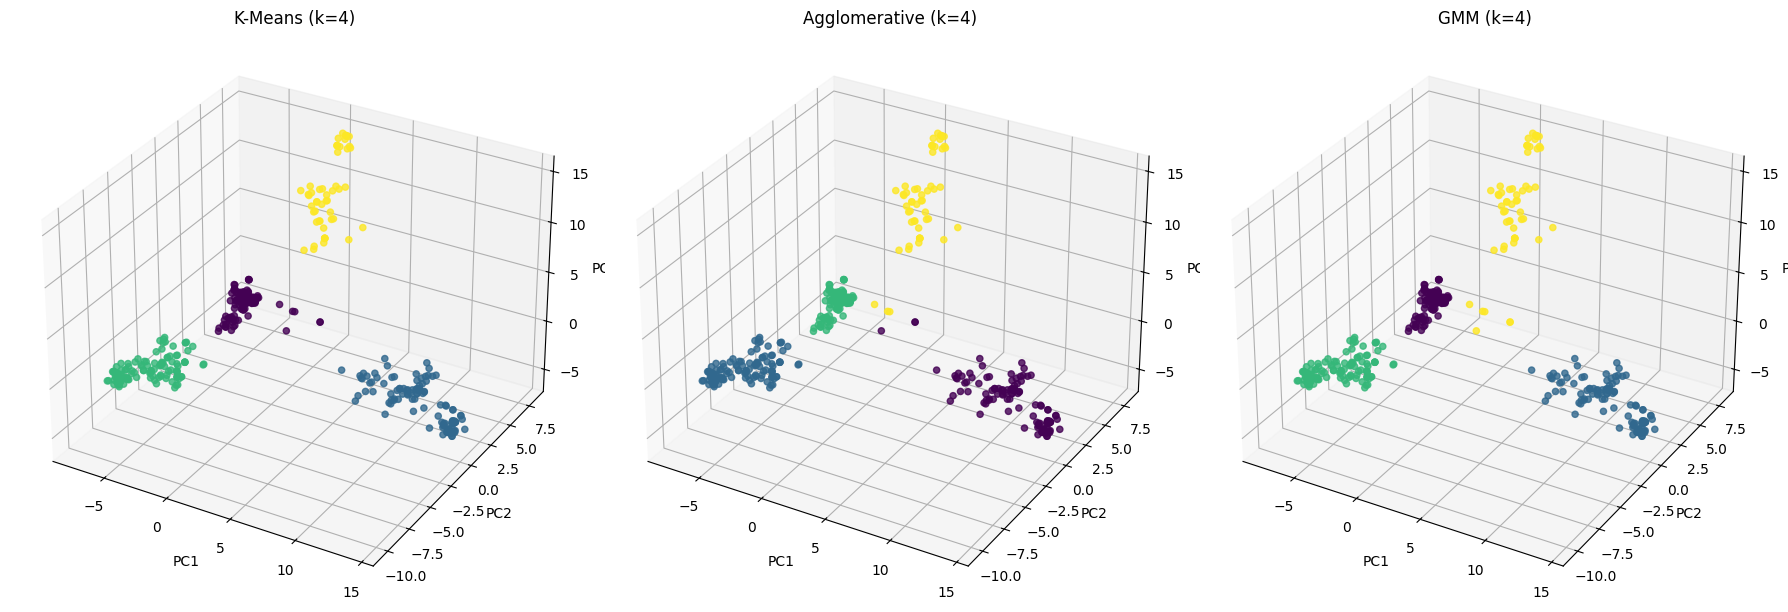

In [189]:
fig = plt.figure(figsize=(18, 6))

# 1. K-Means
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_labels, cmap='viridis', s=20, alpha=0.8)
ax1.set_title('K-Means (k=4)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# 2. Agglomerative
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agg_labels, cmap='viridis', s=20, alpha=0.8)
ax2.set_title('Agglomerative (k=4)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# 3. GMM
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=gmm_labels, cmap='viridis', s=20, alpha=0.8)
ax3.set_title('GMM (k=4)')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')

plt.tight_layout()
plt.show()

In [190]:
def plot_3d(X, data, title_name):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # Pretvaranje stringova u brojeve za bojenje
    color_codes, uniques = pd.factorize(data)
    
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color_codes, cmap='tab10', s=35, alpha=0.8)
    
    ax.set_title(f'3D PCA - {title_name}', fontsize=14)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    
    # Automatska legenda
    handles, _ = scatter.legend_elements(prop='colors', alpha=0.8)
    ax.legend(handles, uniques, title=title_name, loc='best')
    
    plt.tight_layout()
    plt.show()

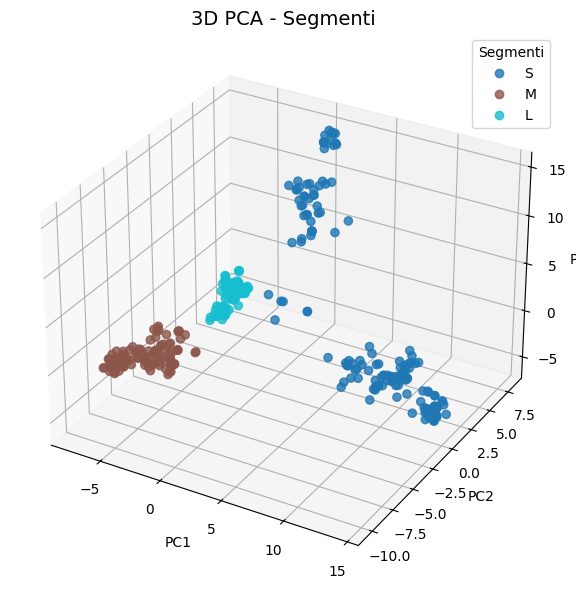

In [191]:
plot_3d(X_pca, data=segments, title_name='Segmenti')

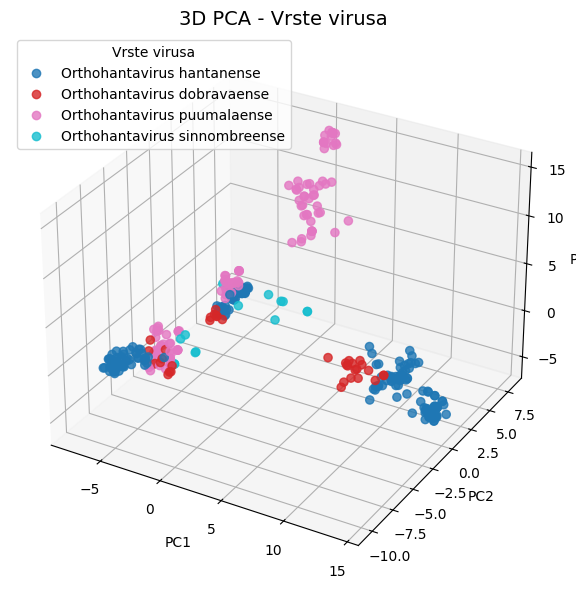

In [192]:
plot_3d(X_pca, data=species, title_name='Vrste virusa')

Vizuelna analiza u svedenom 3D PCA prostoru nedvosmisleno pokazuje da globalnu distribuciju k-mer profila hantavirusa vode genomski segmenti, a ne same vrste. Dok se na prikazu obojenom po segmentima jasno izdvajaju tri klastera (S, M, L), prikaz obojen po vrstama otkriva preklapanje i isprepletanost vrsta virusa. Ovaj empirijski nalaz opravdava naknadnu segment-specifičnu analizu, zarad razdvajanja vrsta unutar svakog segmenta posebno.

# Analiza 4mera svih sekvenci

In [193]:
X_pca_all, pca_all, species_all, segments_all = apply_pca_transformation(all_4_mers)

# K-Means

In [194]:
kmeans_params_all, kmeans_metrics_all, kmeans_labels_all = optimize_and_print_kmeans(X_pca_all, cluster_range=range(2, 8))

=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 5
Izabrani algoritam: lloyd
Način inicijalizacije: random
----------------------------------------
Silhouette Score: 0.5428
Davies-Bouldin Index: 0.5913


In [195]:
df_kmeans_all_eval = pd.DataFrame({'Species': species_all,'Segments' : segments_all ,'Cluster': kmeans_labels_all})

In [196]:
seg_cluster_crosstab = pd.crosstab(df_kmeans_all_eval['Cluster'], df_kmeans_all_eval['Segments'])
print('=== Unakrsna tabela: Klasteri i segmenti (Sve sekvence K-Means) ===')
print(seg_cluster_crosstab)

=== Unakrsna tabela: Klasteri i segmenti (Sve sekvence K-Means) ===
Segments     L     M     S
Cluster                   
0            0   353     0
1         1203  1654    79
2            6    36  1969
3            0    36  1052
4          560     0     5


In [197]:
species_cluster_crosstab = pd.crosstab(df_kmeans_all_eval['Cluster'], df_kmeans_all_eval['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (Sve sekvence K-Means) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (Sve sekvence K-Means) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                 14                         339   
1                                417                        1119   
2                                  2                           2   
3                                319                         675   
4                                 19                          64   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              0  
1                               1160                            240  
2                               1959                             48  
3                                 24                             70  
4                             

Analizom celokupnog skupa podataka uočava se da globalni k-mer prostor počinje da gubi oštre granice razdvajanja, što se posebno vidi kroz preklapanje L i M segmenata unutar zajedničkih klastera (poput klastera 1). Ovo ukazuje na to da parcijalne sekvence donose veću unutrašnju složenost i šum u globalnom prostoru, čineći klasterovanje manje efikasnim.

# Aglomerativno klasterovanje

In [198]:
agg_params_all, agg_metrics_all, agg_labels_all = optimize_and_print_agglomerative(X_pca_all, cluster_range=range(2, 8))

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 5
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.5346
Davies-Bouldin Index: 0.5875


In [199]:
df_agg_all_eval = pd.DataFrame({'Species': species_all, 'Segments': segments_all, 'Cluster': agg_labels_all})

In [200]:
print('=== Unakrsna tabela: Klasteri i segmenti (Sve sekvence - Agglomerative) ===')
print(pd.crosstab(df_agg_all_eval['Cluster'], df_agg_all_eval['Segments']))

print('\n=== Unakrsna tabela: Klasteri i vrste virusa (Sve sekvence - Agglomerative) ===')
print(pd.crosstab(df_agg_all_eval['Cluster'], df_agg_all_eval['Species']))

=== Unakrsna tabela: Klasteri i segmenti (Sve sekvence - Agglomerative) ===
Segments     L     M     S
Cluster                   
0         1248  1675    70
1           49    64  2018
2          472     0     0
3            0   330     0
4            0    10  1017

=== Unakrsna tabela: Klasteri i vrste virusa (Sve sekvence - Agglomerative) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                450                        1188   
1                                  2                           9   
2                                  0                           0   
3                                  0                         330   
4                                319                         672   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                               1122 

# GMM model

In [201]:
gmm_params_all, gmm_metrics_all, gmm_labels_all = optimize_and_print_gmm(X_pca_all, cluster_range=range(2, 8))

=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 5
Tip kovarijanse: tied
----------------------------------------
Silhouette Score: 0.5413
Davies-Bouldin Index: 0.5841


In [202]:
df_gmm_all_eval = pd.DataFrame({'Species': species_all, 'Segments': segments_all, 'Cluster': gmm_labels_all})

In [203]:
print('=== Unakrsna tabela: Klasteri i segmenti (Sve sekvence - GMM) ===')
print(pd.crosstab(df_gmm_all_eval['Cluster'], df_gmm_all_eval['Segments']))

print('\n=== Unakrsna tabela: Klasteri i vrste (Sve sekvence - GMM) ===')
print(pd.crosstab(df_gmm_all_eval['Cluster'], df_gmm_all_eval['Species']))

=== Unakrsna tabela: Klasteri i segmenti (Sve sekvence - GMM) ===
Segments     L     M     S
Cluster                   
0            0    39  1061
1            0   330     0
2         1241  1678    73
3            0    32  1966
4          528     0     5

=== Unakrsna tabela: Klasteri i vrste (Sve sekvence - GMM) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                319                         674   
1                                  0                         330   
2                                443                        1145   
3                                  1                           4   
4                                  8                          46   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                 28                            

# Vizuelizacija klasterovanja svih 4-mera

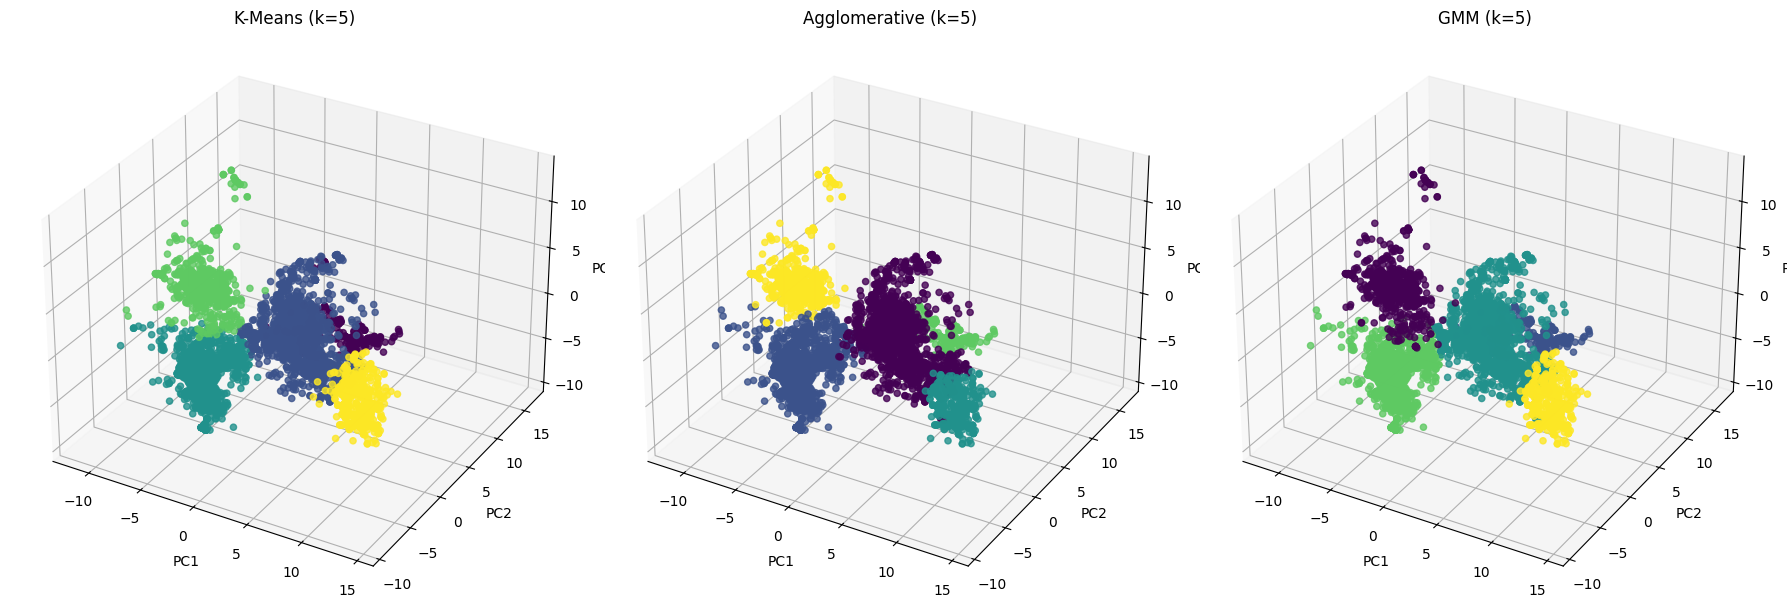

In [204]:
fig = plt.figure(figsize=(18, 6))

# 1. K-Means
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(X_pca_all[:, 0], X_pca_all[:, 1], X_pca_all[:, 2], c=kmeans_labels_all, cmap='viridis', s=20, alpha=0.8)
ax1.set_title('K-Means (k=5)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# 2. Agglomerative
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(X_pca_all[:, 0], X_pca_all[:, 1], X_pca_all[:, 2], c=agg_labels_all, cmap='viridis', s=20, alpha=0.8)
ax2.set_title('Agglomerative (k=5)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# 3. GMM
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(X_pca_all[:, 0], X_pca_all[:, 1], X_pca_all[:, 2], c=gmm_labels_all, cmap='viridis', s=20, alpha=0.8)
ax3.set_title('GMM (k=5)')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')

plt.tight_layout()
plt.show()

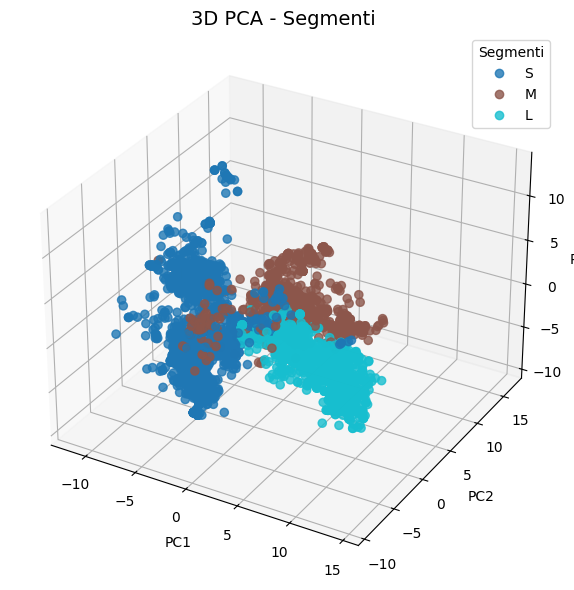

In [205]:
plot_3d(X_pca_all, data=segments_all, title_name='Segmenti')

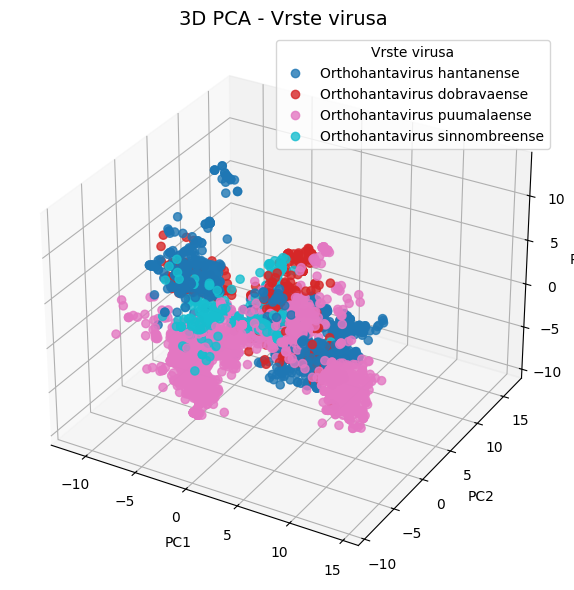

In [206]:
plot_3d(X_pca_all, data=species_all, title_name='Vrste virusa')

Vizuelna 3D PCA analiza celokupnog skupa podataka pruža jasnu potvrdu numeričkim rezultatima. Dok se na prikazu po segmentima (gornji grafik) uočava zadržavanje osnovnih strukturnih celina uz pojavu umerenog preklapanja između segmenata, prikaz obojen po taksonomskim vrstama pokazuje potpuno odsustvo prostorne separacije. Sve vrste hantavirusa formiraju jedinstvenu, isprepletanu masu, čime se vizuelno i konačno potvrđuje da globalni k-mer prostor ne odražava taksonomsku pripadnost vrsta.

In [207]:
print(f'Obuhvaćena varijansa u 3D: {pca_all.explained_variance_ratio_.sum() * 100:.2f}%')

Obuhvaćena varijansa u 3D: 19.36%


Iako trodimenzionalni prikaz obuhvata 19.36% varijanse zadržana je ista osnova radi konzistentnog poređenja sa prethodnim manjim skupom podataka. 

# Eksperiment 2:  Analiza pojedinačnih segmenata (S,M ili L) skupa kompletnih sekvenci

## Izdvajanje i analiza S segmenata

In [208]:
df_s = complete_4_mers[complete_4_mers['Segment'] == 'S'].copy()

X_pca_s, pca_s, species_s, segments_s = apply_pca_transformation(df_s, n_components=3)

print(f'Obuhvaćena varijansa u 3 dimenzije za S segment: {pca_s.explained_variance_ratio_.sum() * 100:.2f}%')

Obuhvaćena varijansa u 3 dimenzije za S segment: 43.06%


In [209]:
kmeans_params_s, kmeans_metrics_s, kmeans_labels_s = optimize_and_print_kmeans(X_pca_s, cluster_range=range(2, 8))

=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 5
Izabrani algoritam: lloyd
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.7242
Davies-Bouldin Index: 0.3868


In [210]:
df_kmeans_s_eval = pd.DataFrame({'Species': species_s, 'Segments': segments_s, 'Cluster': kmeans_labels_s})

print('\n=== Unakrsna tabela: Klasteri i vrste (Kompletne S sekvence - KMeans) ===')
print(pd.crosstab(df_kmeans_s_eval['Cluster'], df_kmeans_s_eval['Species']))


=== Unakrsna tabela: Klasteri i vrste (Kompletne S sekvence - KMeans) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                          44   
1                                  0                           0   
2                                  0                          26   
3                                 18                           0   
4                                  0                          21   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              0  
1                                 53                              4  
2                                  0                              0  
3                                  0                              2  
4                           

Unakrsna analiza između K-Means klastera i stvarnih taksonomskih vrsta na S segmentu pokazuje određenu usklađenost. Dok su neke vrste (poput dobravaense i puumalaense) većinski grupisane u specifičnim klasterima, vrsta hantanense se deli na više pod-klastera (0, 2 i 4).

In [211]:
agg_params_s, agg_metrics_s, agg_labels_s = optimize_and_print_agglomerative(X_pca_s, cluster_range=range(2, 8))

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 5
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.7259
Davies-Bouldin Index: 0.3743


In [212]:
df_agg_eval_s = pd.DataFrame({'Species': species_s,'Segments' : segments_s ,'Cluster': agg_labels_s})
species_cluster_crosstab = pd.crosstab(df_agg_eval_s['Cluster'], df_agg_eval_s['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                           0   
1                                  0                          26   
2                                 18                           0   
3                                  0                          44   
4                                  0                          21   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                 53                              6  
1                                  0                              0  
2                                  0                              0  
3                                  0                              0  
4                                  0 

In [213]:
gmm_params_s, gmm_metrics_s, gmm_labels_s = optimize_and_print_gmm(X_pca_s, cluster_range=range(2, 8))

=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 5
Tip kovarijanse: tied
----------------------------------------
Silhouette Score: 0.7259
Davies-Bouldin Index: 0.3743


In [214]:
df_gmm_eval_s = pd.DataFrame({'Species': species_s,'Segments' : segments_s ,'Cluster': gmm_labels_s})
species_cluster_crosstab = pd.crosstab(df_gmm_eval_s['Cluster'], df_gmm_eval_s['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                          44   
1                                  0                           0   
2                                  0                          26   
3                                 18                           0   
4                                  0                          21   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              0  
1                                 53                              6  
2                                  0                              0  
3                                  0                              0  
4                                  0           

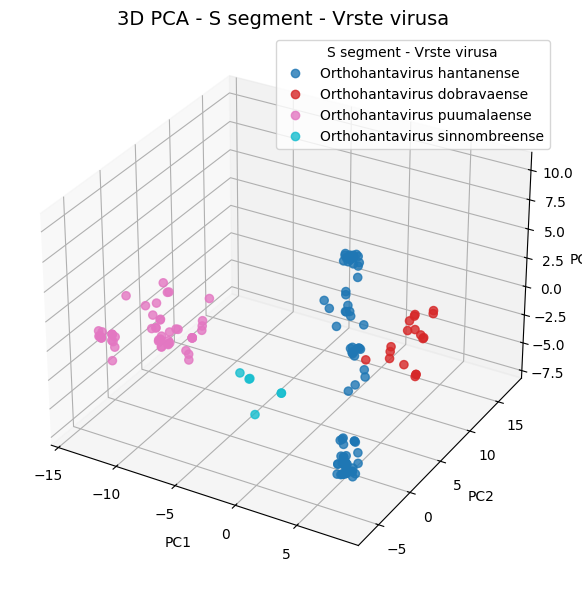

In [215]:
plot_3d(X_pca_s, data=species_s, title_name='S segment - Vrste virusa')

# Izdvajanje i analiza M segmenata

In [216]:
df_m = complete_4_mers[complete_4_mers['Segment'] == 'M'].copy()

X_pca_m, pca_m, species_m, segments_m = apply_pca_transformation(df_m, n_components=3)

print(f'Obuhvaćena varijansa u 3 dimenzije za M segment: {pca_m.explained_variance_ratio_.sum() * 100:.2f}%')

Obuhvaćena varijansa u 3 dimenzije za M segment: 37.05%


In [217]:
kmeans_params_m, kmeans_metrics_m, kmeans_labels_m = optimize_and_print_kmeans(X_pca_m, cluster_range=range(2, 8))

=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 6
Izabrani algoritam: lloyd
Način inicijalizacije: random
----------------------------------------
Silhouette Score: 0.6865
Davies-Bouldin Index: 0.4861


In [218]:
df_kmeans_m_eval = pd.DataFrame({'Species': species_m, 'Segments': segments_m, 'Cluster': kmeans_labels_m})

print('\n=== Unakrsna tabela: Klasteri i vrste (Kompletne M sekvence - KMeans) ===')
print(pd.crosstab(df_kmeans_m_eval['Cluster'], df_kmeans_m_eval['Species']))


=== Unakrsna tabela: Klasteri i vrste (Kompletne M sekvence - KMeans) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                           0   
1                                 12                          28   
2                                  0                           0   
3                                  0                          44   
4                                  0                           0   
5                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                 17                              0  
1                                  0                              0  
2                                  9                              0  
3                             

In [219]:
agg_params_m, agg_metrics_m, agg_labels_m = optimize_and_print_agglomerative(X_pca_m, cluster_range=range(2, 8))

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 6
Izabrana metrika: euclidean
Tip povezivanja: complete
----------------------------------------
Silhouette Score: 0.6865
Davies-Bouldin Index: 0.4861


In [220]:
df_agg_eval_m = pd.DataFrame({'Species': species_m,'Segments' : segments_m ,'Cluster': agg_labels_m})
species_cluster_crosstab = pd.crosstab(df_agg_eval_m['Cluster'], df_agg_eval_m['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                 12                          28   
1                                  0                           0   
2                                  0                           0   
3                                  0                          44   
4                                  0                           0   
5                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              0  
1                                 17                              0  
2                                  3                              6  
3                                  0   

In [221]:
gmm_params_m, gmm_metrics_m, gmm_labels_m = optimize_and_print_gmm(X_pca_m, cluster_range=range(2, 8))

df_gmm_eval_m = pd.DataFrame({'Species': species_m,'Segments' : segments_m ,'Cluster': gmm_labels_m})

=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 4
Tip kovarijanse: full
----------------------------------------
Silhouette Score: 0.6499
Davies-Bouldin Index: 0.6368


In [222]:
species_cluster_crosstab = pd.crosstab(df_gmm_eval_m['Cluster'], df_gmm_eval_m['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                          44   
1                                  0                           0   
2                                 12                          28   
3                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              0  
1                                 16                              6  
2                                  0                              0  
3                                 23                              0  


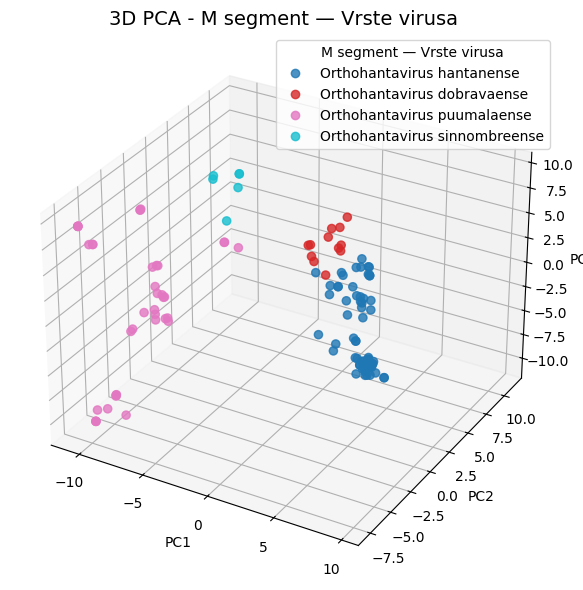

In [223]:
plot_3d(X_pca_m, data=species_m, title_name='M segment — Vrste virusa')

## Izdvajanje i analiza L segmenata

In [224]:
df_l = complete_4_mers[complete_4_mers['Segment'] == 'L'].copy()

X_pca_l, pca_l, species_l, segments_l = apply_pca_transformation(df_l, n_components=3)

print(f'Obuhvaćena varijansa u 3D za L segment: {pca_l.explained_variance_ratio_.sum() * 100:.2f}%')

Obuhvaćena varijansa u 3D za L segment: 44.31%


In [225]:
kmeans_params_l, kmeans_metrics_l, kmeans_labels_l = optimize_and_print_kmeans(X_pca_l, cluster_range=range(2, 8))

=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 4
Izabrani algoritam: lloyd
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.7724
Davies-Bouldin Index: 0.5444


In [226]:
df_kmeans_l_eval = pd.DataFrame({'Species': species_l, 'Segments': segments_l, 'Cluster': kmeans_labels_l})

print('\n=== Unakrsna tabela: Klasteri i vrste (Kompletne L sekvence - KMeans) ===')
print(pd.crosstab(df_kmeans_l_eval['Cluster'], df_kmeans_l_eval['Species']))


=== Unakrsna tabela: Klasteri i vrste (Kompletne L sekvence - KMeans) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                          69   
1                                  0                           0   
2                                  7                           5   
3                                  0                          12   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              0  
1                                 31                              0  
2                                  0                              6  
3                                  0                              0  


In [227]:
agg_params_l, agg_metrics_l, agg_labels_l = optimize_and_print_agglomerative(X_pca_l, cluster_range=range(2, 8))

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 4
Izabrana metrika: euclidean
Tip povezivanja: complete
----------------------------------------
Silhouette Score: 0.7738
Davies-Bouldin Index: 0.3930


In [228]:
df_agg_eval_l = pd.DataFrame({'Species': species_l,'Segments' : segments_l ,'Cluster': agg_labels_l})
species_cluster_crosstab = pd.crosstab(df_agg_eval_l['Cluster'], df_agg_eval_l['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (Agglomerative) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                           0   
1                                  7                           0   
2                                  0                          74   
3                                  0                          12   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                 31                              1  
1                                  0                              5  
2                                  0                              0  
3                                  0                              0  


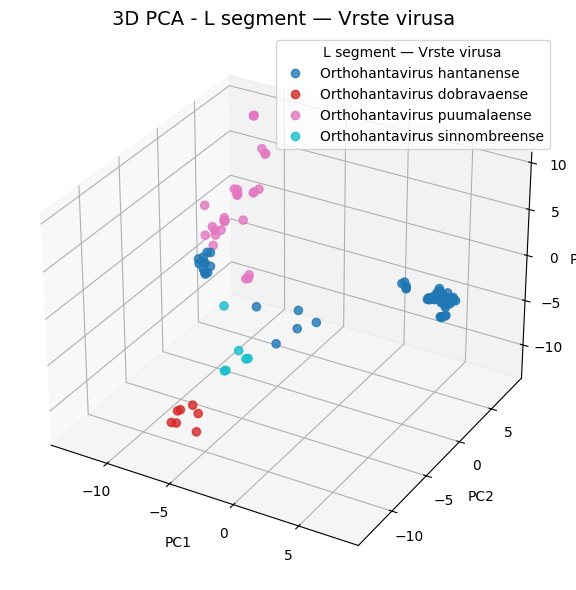

In [229]:
plot_3d(X_pca_l, data=species_l, title_name='L segment — Vrste virusa')

In [230]:
gmm_params_l, gmm_metrics_l, gmm_labels_l = optimize_and_print_gmm(X_pca_l, cluster_range=range(2, 8))

df_gmm_eval_l = pd.DataFrame({'Species': species_l,'Segments' : segments_l ,'Cluster': gmm_labels_l})

=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 4
Tip kovarijanse: full
----------------------------------------
Silhouette Score: 0.7643
Davies-Bouldin Index: 0.5634


In [231]:
species_cluster_crosstab = pd.crosstab(df_gmm_eval_l['Cluster'], df_gmm_eval_l['Species'])
print('\n=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===')
print(species_cluster_crosstab)


=== Unakrsna tabela: Klasteri i vrste virusa (GMM) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                          69   
1                                  7                           5   
2                                  0                          12   
3                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                  0                              0  
1                                  3                              6  
2                                  0                              0  
3                                 28                              0  


# Eksperiment 3: Analiza S segmenata skupa svih sekvenci

In [232]:
df_s_all = all_4_mers[all_4_mers['Segment'] == 'S'].copy()

X_pca_s_all, pca_s_all, species_s_all, segments_s_all = apply_pca_transformation(df_s_all, n_components=3)

print(f'Obuhvaćena varijansa u 3 dimezije za S segment: {pca_s_all.explained_variance_ratio_.sum() * 100:.2f}%')

Obuhvaćena varijansa u 3 dimezije za S segment: 23.46%


In [233]:
kmeans_params_s, kmeans_metrics_s, kmeans_labels_s = optimize_and_print_kmeans(X_pca_s_all, cluster_range=range(2, 8))

=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 7
Izabrani algoritam: lloyd
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.4701
Davies-Bouldin Index: 0.7276


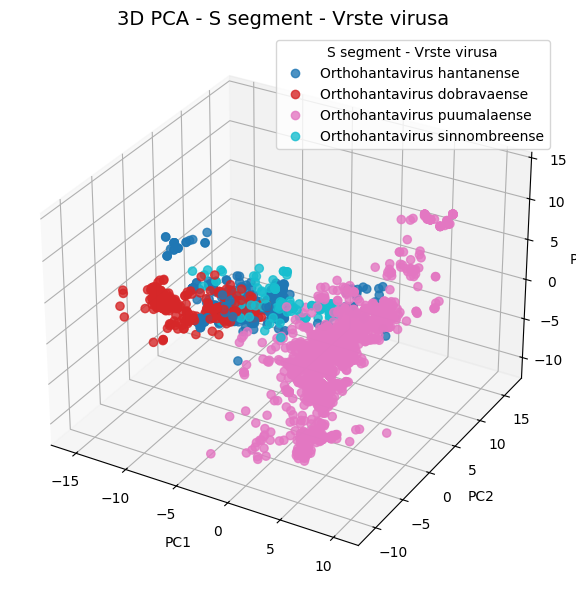

In [234]:
plot_3d(X_pca_s_all, data=species_s_all, title_name='S segment - Vrste virusa')

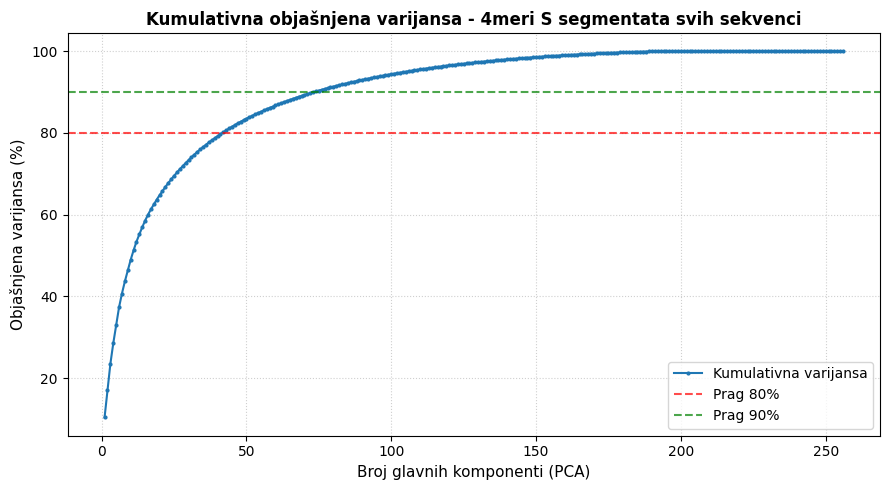

eri S segmentata svih sekvenci] Broj komponenti za 80% varijanse: 42
eri S segmentata svih sekvenci] Broj komponenti za 90% varijanse: 74


In [235]:
plot_cumulative_variance(df_s_all,'4meri S segmentata svih sekvenci')

## Pokušaj klasterovanja skupova gde je sačuvano 80 posto varijanse podataka

In [236]:
df_s_all = all_4_mers[all_4_mers['Segment'] == 'S'].copy()
X_pca_s_all, pca_s_all, species_s_all, segments_s_all = apply_pca_transformation(df_s_all, n_components=0.8)

In [237]:
kmeans_params_s, kmeans_metrics_s, kmeans_labels_s = optimize_and_print_kmeans(X_pca_s_all, cluster_range=range(2, 8))

=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 5
Izabrani algoritam: lloyd
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.1799
Davies-Bouldin Index: 2.0300


In [238]:
df_kmeans_s_all_eval = pd.DataFrame({'Species': species_s_all, 'Cluster': kmeans_labels_s})

In [239]:
print('\n=== Unakrsna tabela: Klasteri i vrste (S sekvence - KMeans) ===')
print(pd.crosstab(df_kmeans_s_all_eval['Cluster'], df_kmeans_s_all_eval['Species']))


=== Unakrsna tabela: Klasteri i vrste (S sekvence - KMeans) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                           0   
1                                 28                         691   
2                                290                           2   
3                                  0                           3   
4                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                292                              0  
1                                 33                            104  
2                                  0                              0  
3                               1402                              2  
4                                258  

Analiza unakrsne tabele i primena K-Means algoritma u prostoru višeg dimenzionalnog opsega (42 komponente, koje obuhvataju 80.16% kumulativne varijanse S segmenta svih sekvenci) otkrivaju složenu strukturu podataka kada se uključe nekompletne sekvence. Iako silueta koeficijent opada usled prirodnog šuma i veće dimenzionalnosti (pomenut problem prokletstva dimenzionalnosti), unakrsna tabela pokazuje da algoritam uspešno izdvaja pojedine grupe. Na primer, vrsta orthohantavirus dobravaense se dominantno izolovala u drugi klaster (sa 290 od ukupno 318 instanci). S druge strane, mnogobrojna grupa orthohantavirus puumalaense se usled velikog obima i parcijalnih zapisa podelila na više podklastera. Ovi rezultati dodatno naglašavaju izazove u radu sa heterogenim bazama podataka i opravdavaju primarnu upotrebu kompletnih genoma za taksonomsku separaciju.

In [240]:
agg_params_s, agg_metrics_s, agg_labels_s = optimize_and_print_agglomerative(X_pca_s_all, cluster_range=range(2, 9))

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 2
Izabrana metrika: euclidean
Tip povezivanja: complete
----------------------------------------
Silhouette Score: 0.4677
Davies-Bouldin Index: 0.7225


In [241]:
df_agg_s_all_eval = pd.DataFrame({'Species': species_s_all, 'Cluster': agg_labels_s})

In [242]:
print('\n=== Unakrsna tabela: Klasteri i  vrste (S sekvence) ===')
print(pd.crosstab(df_agg_s_all_eval['Cluster'], df_agg_s_all_eval['Species']))


=== Unakrsna tabela: Klasteri i  vrste (S sekvence) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                318                         696   
1                                  0                           0   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                               1985                             95  
1                                  0                             11  


Iako hijerarhijsko klasterovanje postiže viši silueta koeficijent (0.4677), unakrsna tabela otkriva da algoritam degeneriše rešenje spajanjem većine instanci u jedan masivan klaster, uz minimalnu separaciju u drugi klaster.

In [243]:
gmm_params_s, gmm_metrics_s, gmm_labels_s = optimize_and_print_gmm(X_pca_s_all, cluster_range=range(2, 9))

=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 8
Tip kovarijanse: tied
----------------------------------------
Silhouette Score: 0.2031
Davies-Bouldin Index: 1.9529


In [244]:
df_gmm_s_all_eval = pd.DataFrame({'Species': species_s_all, 'Cluster': gmm_labels_s})

In [245]:
print('\n=== Unakrsna tabela: Klasteri i vrste (S sekvence) ===')
print(pd.crosstab(df_gmm_s_all_eval['Cluster'], df_gmm_s_all_eval['Species']))


=== Unakrsna tabela: Klasteri i vrste (S sekvence) ===
Species  Orthohantavirus dobravaense  Orthohantavirus hantanense  \
Cluster                                                            
0                                  0                           0   
1                                  0                         689   
2                                  0                           6   
3                                  0                           0   
4                                318                           0   
5                                  0                           0   
6                                  0                           0   
7                                  0                           1   

Species  Orthohantavirus puumalaense  Orthohantavirus sinnombreense  
Cluster                                                              
0                                269                              0  
1                                 11                 

Primenom GMM algoritma klasterovanja dobijeni su zanimljivi rezultati. Sve instance orthohantavirus dobravaense izolovane su u zaseban klaster, bez ikakvog mešanja sa drugim vrstama. Ovaj rezultat ukazuje da S segment ove vrste ima prepoznatljiv 4-mer profil. Što se tiče virusa orthohantavirus hantanense velika većina instanci je smeštena u prvi klaster. Instance virusa orthohantavirus sinnombreense podeljene su između drugog i poslednjeg klastera. 

Za razliku od ostalih virusa, najbrojniji virus orthohantavirus puumalaense je ponovo rasut kroz skoro sve klastere, pa 4-meri ovog virusa pokazuju veliki diverzitet.

Važno je napomenuti da se u nenadgledanom pristupu parametri ne smeju prilagođavati sa ciljem da se po poklope sa poznatim taksonomskim oznakama (vrstama), jer bi to predstavljalo prikriveno nadgledano učenje, tj. došlo bi do curenja podataka. Činjenica da standardni algoritmi (poput K-Means, hijerarhijskog klasterovanja i gmm) nad celokupnim skupom nekompletnih sekvenci ne uspevaju automatski da razdvoje sve vrste virusa ukazuje na to da njihova pouzdana biološka separacija zahteva primenu metoda nadgledanog učenja.